# Tune + Eigenmode

In [1]:
import sys
sys.path.append("../..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
%matplotlib widget
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import pprint
pp = pprint.PrettyPrinter(indent=4)

{   'cav_tune_eig': {   'end-cell': {   'FREQ': 801.5799995642193,
                                        'TUNED VARIABLES': ['L_el'],
                                        'parameters': {   'A_el': 62.22,
                                                          'B_el': 66.13,
                                                          'L_el': 114.04967197777749,
                                                          'Req_el': 174.6214489755719,
                                                          'Ri_el': 80.0,
                                                          'a_el': 30.22,
                                                          'b_el': 23.11}},
                        'mid-cell': {   'FREQ': 801.5799904990349,
                                        'TUNED VARIABLES': ['Req_m'],
                                        'parameters': {   'A_m': 62.22,
                                                          'B_m': 66.13,
                                           

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

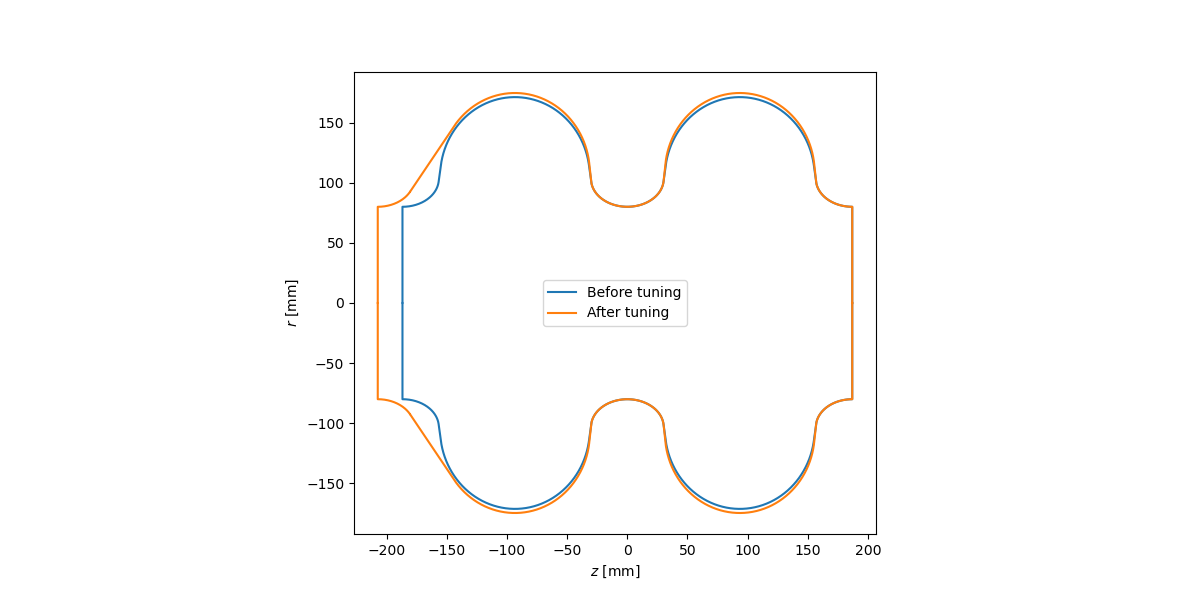

In [ ]:
# define geometry parameters
midcell = np.array([42.0, 23.0, 42.5, 57.5, 70.24238959559739, 93.5, 170.0, 0])
endcell = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])
endcell_r = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])

# create cavity
cav_tune_eig = EllipticalCavity(1, midcell, midcell, midcell, beampipe='none')
ax = cav_tune_eig.plot('geometry', label='Before tuning')

cavs_tune_eig = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations',
overwrite=True
)

cavs_tune_eig.add_cavity(cav_tune_eig, 'cav_tune_eig')

tune_config = {
    'freqs': 801.58,
    'cell_type': {
        'mid-cell': 'Req',
        'end-cell': 'L'
    },
    'processes': 1,
    'rerun': True,
    'eigenmode_config': {
        'processes': 3,
        'rerun': True,
        'boundary_conditions': 'mm',
    },
}
cavs_tune_eig.run_tune(tune_config)
pp.pprint(cavs_tune_eig.tune_results)

# plot geometry after tuning
cavs_tune_eig.tuned.plot('geometry', ax, label='After tuning')

In [ ]:
ax_obj_dict = cavs_tune_eig.save_plot_as_json(ax)

In [ ]:
cavs_tune_eig.plot_from_json(ax_obj_dict)

In [ ]:
cavs_tune_eig.plot('convergence')
plt.show()

# Tune (+UQ) + Eigenmode

In [ ]:
import sys
sys.path.append("..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
%matplotlib inline
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import pprint
pp = pprint.PrettyPrinter(indent=4)

# define geometry parameters
midcell = np.array([42.0, 23.0, 42.5, 57.5, 70.24238959559739, 93.5, 170.0, 0])
endcell = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])
endcell_r = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])

# create cavity
cav_tune_uq_eig = EllipticalCavity(1, midcell, endcell, endcell, beampipe='both')
ax = cav_tune_uq_eig.plot('geometry', label='Before tuning')

cavs_tune_uq_eig = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

cavs_tune_uq_eig.add_cavity(cav_tune_uq_eig, 'cav_tune_uq_eig')

tune_config = {
    'freqs': 801.58,
    'cell_type': {
        'mid-cell': 'Req',
    },
    'processes': 1,
    'rerun': True,
    'eigenmode_config': {
        'processes': 3,
        'rerun': True,
        'boundary_conditions': 'mm',
    },
    'uq_config': {
        'variables': ['A', 'B', 'a', 'b'],
        'delta': [0.05, 0.05, 0.05, 0.05],
        'objectives': ["freq [MHz]"],
        'processes': 4,
        'method': ['Quadrature', 'Stroud3'],
        'cell_type': 'mid-cell',
        'cell complexity': 'simplecell'
        }
}
cavs_tune_uq_eig.run_tune(tune_config)
pp.pprint(cavs_tune_uq_eig.tune_results)

# plot geometry after tuning
cavs_tune_uq_eig.plot('geometry', ax, label='After tuning')

# Tune + Eigenmode (+UQ)

In [ ]:
import sys
sys.path.append("..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
%matplotlib inline
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import pprint
pp = pprint.PrettyPrinter(indent=4)

# define geometry parameters
midcell = np.array([42.0, 23.0, 42.5, 57.5, 70.24238959559739, 93.5, 170.0, 0])
endcell = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])
endcell_r = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])


# create cavity
cav_tune_eig_uq = EllipticalCavity(1, midcell, endcell, endcell, beampipe='both')
ax = cav_tune_eig_uq.plot('geometry', label='Before tuning')

cavs_tune_eig_uq = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

cavs_tune_eig_uq.add_cavity(cav_tune_eig_uq, 'cav_tune_eig_uq')

tune_config = {
    'freqs': 801.58,
    'cell_type': {
        'mid-cell': 'Req',
    },
    'processes': 1,
    'rerun': True,
    'eigenmode_config': {
        'processes': 3,
        'rerun': True,
        'boundary_conditions': 'mm',
        'uq_config': {
            'variables': ['A', 'B', 'a', 'b'],
            'objectives': ["freq [MHz]", "Epk/Eacc []", "Bpk/Eacc [mT/MV/m]", "R/Q [Ohm]", "G [Ohm]"],
            'delta': [0.05, 0.05, 0.05, 0.05],
            'processes': 4,
            'distribution': 'gaussian',
            'method': ['Quadrature', 'Stroud3'],
            'cell_type': 'mid-cell',
            'cell complexity': 'simplecell'
            }
    },
}
cavs_tune_eig_uq.run_tune(tune_config)
pp.pprint(cavs_tune_eig_uq.tune_results)

# plot geometry after tuning
cavs_tune_eig_uq.tuned.plot('geometry', ax, label='After tuning')

# Tune (+UQ) + Eigenmode (+UQ)

In [ ]:
import sys
sys.path.append("..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
%matplotlib inline
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities, OperationPoints
import pprint
pp = pprint.PrettyPrinter(indent=4)

# define geometry parameters
# midcell = np.array([42.0, 23.0, 42.5, 57.5, 70.24238959559739, 93.5, 170.0, 0])
# endcell = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])
# endcell_r = np.array([47.0, 23.0, 42.5, 57.5, 70.59919028624745, 93.5, 170.0, 0])
midcell = np.array([42, 42, 12, 19, 35, 57.76524, 103])
endcell = np.array([40.34, 40.34, 10, 13.5, 39, 51, 103.353])
endcell_r = np.array([42, 42, 9, 12.8, 39, 51, 103.353])

# create cavity — TESLA-like 5-cell with beampipes; tune both mid-cell and
# end-cell so the full-cavity eigenmode matches the target frequency.
cav_tune_uq_eig_uq = EllipticalCavity(5, midcell, endcell, endcell_r, beampipe='both')
ax = cav_tune_uq_eig_uq.plot('geometry', label='Before tuning')

cavs_tune_uq_eig_uq = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

cavs_tune_uq_eig_uq.add_cavity(cav_tune_uq_eig_uq, 'cav_tune_uq_eig_uq')

tune_config = {
    'freqs': 1300,
    # Consecutive tune: mid-cell first, its result feeds into end-cell.
    'cell_type': {
        'mid-cell': 'Req',
        'end-cell': 'L',
        'end-cell-r': 'L',
    },
    'processes': 1,
    'rerun': True,
    'eigenmode_config': {
        'processes': 3,
        'rerun': True,
        'boundary_conditions': 'mm',
        'uq_config': {
            'variables': ['A', 'B', 'a', 'b'],
            'objectives': ["freq [MHz]", "Epk/Eacc []", "Bpk/Eacc [mT/MV/m]", "R/Q [Ohm]", "G [Ohm]"],
            'delta': [0.05, 0.05, 0.05, 0.05],
            'processes': 4,
            'distribution': 'gaussian',
            'method': ['Quadrature', 'Stroud3'],
            'cell_type': 'mid-cell',
            'cell complexity': 'simplecell'
            }
    },
    'uq_config': {
        'variables': ['A', 'B', 'a', 'b'],
        'delta': [0.05, 0.05, 0.05, 0.05],
        'objectives': ["freq [MHz]"],
        'processes': 4,
        'method': ['Quadrature', 'Stroud3'],
        'cell_type': 'mid-cell',
        'cell complexity': 'simplecell'
        }
}
cavs_tune_uq_eig_uq.run_tune(tune_config)
pp.pprint(cavs_tune_uq_eig_uq.tune_results)

# plot geometry after tuning
# cavs_tune_uq_eig_uq.tuned.plot('geometry', ax, label='After tuning')

In [ ]:
print(cavs_tune_uq_eig_uq.tuned.uq_fm_results)